# Columnar Simulations: Exploring `simulations-columnar.h5`

This notebook explores the **columnar** simulated dataset (`config/simulation/columnar.yaml`,
`data/simulations-columnar.h5`) that trains the columnar `MICH` model. Unlike the 2-D "sheet"
simulations in `01_running_simulations.ipynb`, columnar data represents cortex as ~750
spatially-**independent** columns per layer instead of a 2-D grid with a point-spread function (PSF):

- No PSF (`bold.psf_fwhm_mm: [0.0, 0.0]`) -- imaging/vascular blur is assumed already subsumed by the
  ~10-voxel-per-column averaging that happens upstream, in the real acquisition pipeline.
- No inter-column diffusion (`diffusion_coefficient_intra: 0.0`) -- no coupling mechanism links one
  column's neural activity to its neighbours.

Structurally, this is represented as a **degenerate width-1 sheet**: `grid_size=[num_columns, 1]`, so
every tensor still has the familiar `[..., H, W]` shape from the sheet case, just with `W=1`. This
notebook makes that concrete and visually verifies the independence claim.

In [1]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (REPO_ROOT / "src" / "mich").exists(), f"Expected repo root, got {REPO_ROOT}"

DATA_PATH = REPO_ROOT / "data" / "simulations-columnar.h5"
assert DATA_PATH.exists(), f"{DATA_PATH} not found -- run: python scripts/run_sim.py --config-name columnar num_simulations=1000"

%matplotlib inline

## 1. Dataset overview

Read the stored config (`/meta`'s `config` JSON attribute) to confirm the columnar-specific settings,
then peek at the dataset shapes.

In [2]:
with h5py.File(DATA_PATH, "r") as f:
    cfg = json.loads(f["meta"].attrs["config"])
    layer_keys = sorted(k for k in f.keys() if k.startswith("layer"))
    num_sims, T, num_columns, W = f[layer_keys[0]]["bold"].shape

print(f"layers: {layer_keys}")
print(f"bold/x shape per layer: (num_sims={num_sims}, T={T}, num_columns={num_columns}, W={W})")
print()
print("Columnar-specific config:")
print(f"  simulation.grid_size            = {cfg['simulation']['grid_size']}  (degenerate: [num_columns, 1])")
print(f"  simulation.diffusion_coefficient_intra = {cfg['simulation']['diffusion_coefficient_intra']}  (0.0 -> no coupling between columns)")
print(f"  simulation.neural_noise_type     = {cfg['simulation'].get('neural_noise_type')}  ('white', not 'pink' -- avoids reintroducing cross-column correlation)")
print(f"  simulation.source_placement      = {cfg['simulation']['source_placement']}  (shared_position=True -- a real column spans all active layers)")
print(f"  bold.psf_fwhm_mm                 = {cfg['bold']['psf_fwhm_mm']}  (0.0 -> no PSF)")
print(f"  derived bold.psf_fwhm (grid units) = {cfg['bold'].get('psf_fwhm')}")


layers: ['layer_0', 'layer_1', 'layer_2']
bold/x shape per layer: (num_sims=5000, T=100, num_columns=750, W=1)

Columnar-specific config:
  simulation.grid_size            = [750, 1]  (degenerate: [num_columns, 1])
  simulation.diffusion_coefficient_intra = 0.0  (0.0 -> no coupling between columns)
  simulation.neural_noise_type     = white  ('white', not 'pink' -- avoids reintroducing cross-column correlation)
  simulation.source_placement      = {'sources_per_layer': [1, 1], 'shared_position': True, 'shared_pulse': False}  (shared_position=True -- a real column spans all active layers)
  bold.psf_fwhm_mm                 = [0.0, 0.0]  (0.0 -> no PSF)
  derived bold.psf_fwhm (grid units) = [0.0, 0.0, 0.0]


## 2. Load a subset for plotting

`num_sims` here is in the hundreds-to-thousands, which is fine for training but too much to load
wholesale into a notebook (each dataset is `(num_sims, T, num_columns, 1)` float16). We only need a
handful of samples to visualize, so we slice the first `N_DEMO` simulations directly out of HDF5.

In [3]:
N_DEMO = 24

with h5py.File(DATA_PATH, "r") as f:
    bold = np.stack([f[lk]["bold"][:N_DEMO] for lk in layer_keys], axis=1)  # (N, L, T, C, 1)
    x = np.stack([f[lk]["x"][:N_DEMO] for lk in layer_keys], axis=1)
    num_sources = f["meta"]["num_sources"][:N_DEMO]
    source_layer = f["meta"]["sources"]["layer"][:N_DEMO]          # (N, max_sources)
    source_position = f["meta"]["sources"]["position"][:N_DEMO, :, 0]  # (N, max_sources) -- column index (trailing [i, j=0] pair collapsed)

bold = bold[..., 0]  # drop the degenerate W=1 axis -> (N, L, T, C)
x = x[..., 0]
print("bold:", bold.shape, "  x:", x.shape)
print("example sample 0 sources: layers=", source_layer[0][:num_sources[0]], " columns=", source_position[0][:num_sources[0]])


bold: (24, 3, 100, 750)   x: (24, 3, 100, 750)
example sample 0 sources: layers= [2 1]  columns= [324 324]


## 3. One sample, close up: source-column traces

For one simulation, plot the neural drive `x(t)` and BOLD `(t)` at the shared source column, for every
active layer -- this is the columnar analog of the "source voxel" plot in `01_running_simulations.ipynb`,
just indexed by a single column rather than `(h, w)`.

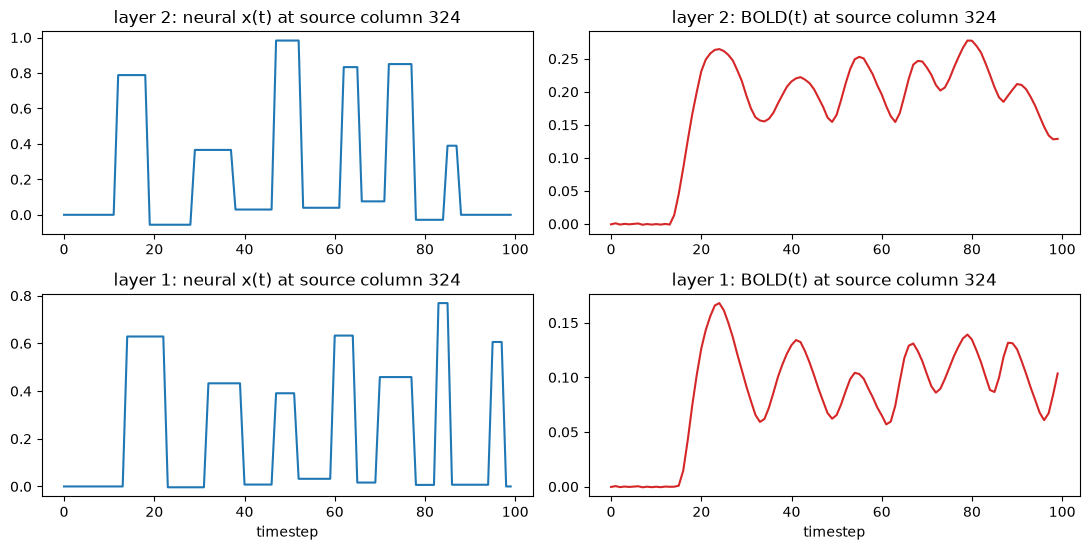

In [4]:
sample_idx = 0
active_layers = source_layer[sample_idx][: num_sources[sample_idx]]
src_col = int(source_position[sample_idx][0])  # shared_position -> same column for every active layer

fig, axes = plt.subplots(len(active_layers), 2, figsize=(11, 2.8 * len(active_layers)), squeeze=False)
for row, layer in enumerate(active_layers):
    axes[row, 0].plot(x[sample_idx, layer, :, src_col], color="tab:blue")
    axes[row, 0].set_title(f"layer {layer}: neural x(t) at source column {src_col}")
    axes[row, 1].plot(bold[sample_idx, layer, :, src_col], color="tab:red")
    axes[row, 1].set_title(f"layer {layer}: BOLD(t) at source column {src_col}")
for ax in axes[-1]:
    ax.set_xlabel("timestep")
plt.tight_layout()
plt.show()


## 4. The full column axis: `[C, T]` heatmaps

This is the plot that wouldn't have made sense with the old sheet-based `make_evolution_gif`
(an animated 2-D `imshow` of an `H x 1` field is a one-pixel-wide sliver). With columns as the real
spatial axis, a `[C, T]` heatmap is the natural way to see the whole grid over time at once.

Look for: a single bright row (the source column) against an otherwise flat/uniform background --
this **is** the independence property. With no PSF and no diffusion, there is no mechanism left for the
signal to spread into neighbouring columns, so unlike the old sheet+PSF model, you won't see any blur.

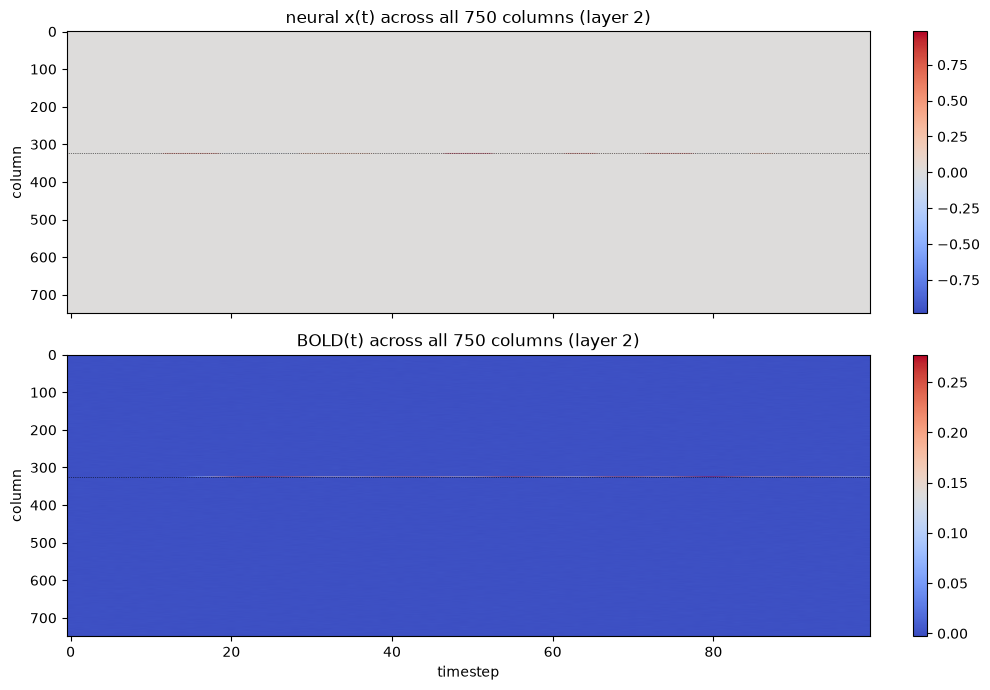

neural x away from the source column is exactly zero (no diffusion, no neural-level noise in this config):
  max |x| off-source: 0.0
  max |x| at source:  0.983


In [5]:
layer_to_show = active_layers[0]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

im0 = axes[0].imshow(x[sample_idx, layer_to_show].T, aspect="auto", cmap="coolwarm",
                      vmin=-np.abs(x[sample_idx, layer_to_show]).max(), vmax=np.abs(x[sample_idx, layer_to_show]).max())
axes[0].set_title(f"neural x(t) across all {num_columns} columns (layer {layer_to_show})")
axes[0].set_ylabel("column")
axes[0].axhline(src_col, color="k", linewidth=0.5, linestyle=":")
plt.colorbar(im0, ax=axes[0], fraction=0.02)

im1 = axes[1].imshow(bold[sample_idx, layer_to_show].T, aspect="auto", cmap="coolwarm")
axes[1].set_title(f"BOLD(t) across all {num_columns} columns (layer {layer_to_show})")
axes[1].set_ylabel("column")
axes[1].set_xlabel("timestep")
axes[1].axhline(src_col, color="k", linewidth=0.5, linestyle=":")
plt.colorbar(im1, ax=axes[1], fraction=0.02)

plt.tight_layout()
plt.show()

print("neural x away from the source column is exactly zero (no diffusion, no neural-level noise in this config):")
off_source_cols = [c for c in range(num_columns) if c != src_col]
print("  max |x| off-source:", np.abs(x[sample_idx, layer_to_show][:, off_source_cols]).max())
print("  max |x| at source: ", np.abs(x[sample_idx, layer_to_show][:, src_col]).max())

## 5. Verifying independence across many samples: source vs. random other columns

A single heatmap is convincing but anecdotal. Here we check, across all `N_DEMO` loaded samples, that
each sample's BOLD at its own source column is essentially uncorrelated with BOLD at a few randomly
chosen *other* columns -- the off-source columns carry only baseline + independent noise, no trace of
the source's evoked response.

source-vs-self correlation (sanity check): 1.000
source-vs-random-other-column correlation: mean=0.004, std=0.110


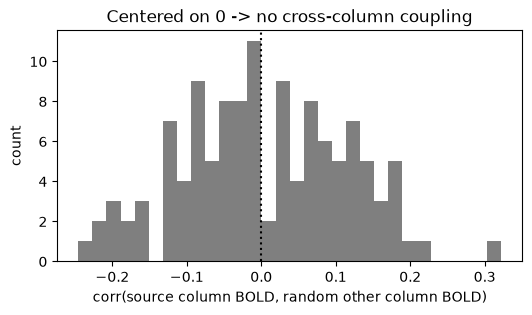

In [6]:
rng = np.random.default_rng(0)
same_source_corrs = []
other_column_corrs = []

for i in range(N_DEMO):
    layer = int(source_layer[i][0])
    col = int(source_position[i][0])
    src_trace = bold[i, layer, :, col]
    same_source_corrs.append(np.corrcoef(src_trace, src_trace)[0, 1])  # trivially 1.0, sanity check

    other_cols = rng.choice([c for c in range(num_columns) if c != col], size=5, replace=False)
    for oc in other_cols:
        other_trace = bold[i, layer, :, oc]
        other_column_corrs.append(np.corrcoef(src_trace, other_trace)[0, 1])

other_column_corrs = np.array(other_column_corrs)
print(f"source-vs-self correlation (sanity check): {np.mean(same_source_corrs):.3f}")
print(f"source-vs-random-other-column correlation: mean={other_column_corrs.mean():.3f}, std={other_column_corrs.std():.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(other_column_corrs, bins=30, color="tab:gray")
ax.axvline(0.0, color="k", linestyle=":")
ax.set_xlabel("corr(source column BOLD, random other column BOLD)")
ax.set_ylabel("count")
ax.set_title("Centered on 0 -> no cross-column coupling")
plt.show()


## 6. Variability across simulations

Each simulation randomly draws which layers are active, where the shared source column sits, and the
pulse train driving it. A small grid of source-column BOLD traces shows this variability.

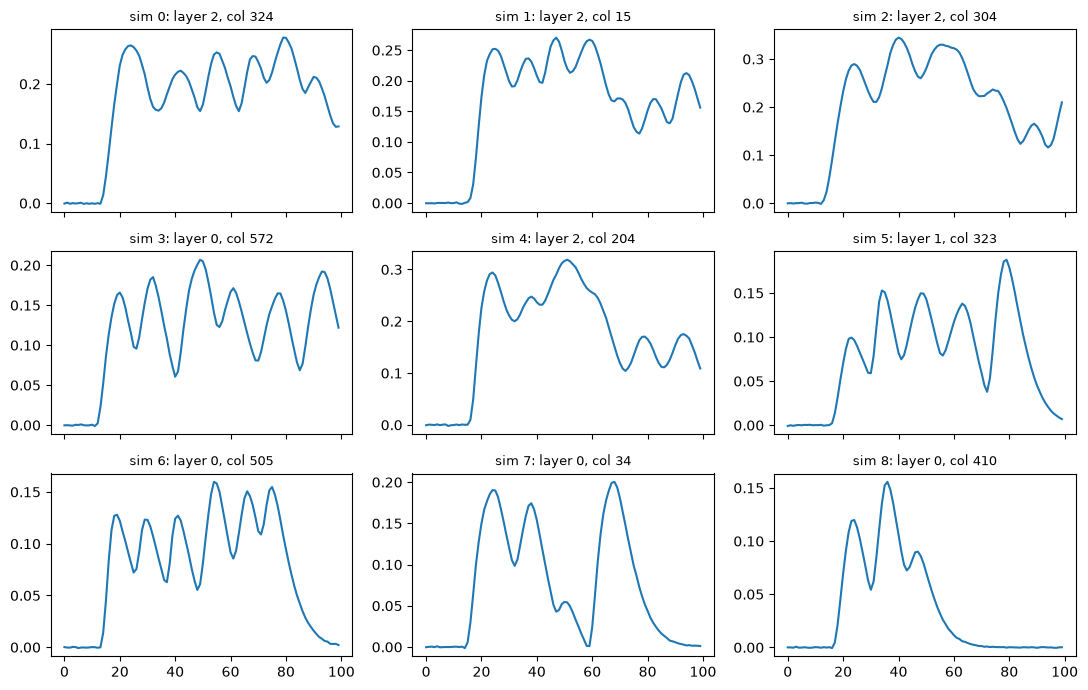

In [7]:
n_show = 9
fig, axes = plt.subplots(3, 3, figsize=(11, 7), sharex=True)
for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue
    layer = int(source_layer[i][0])
    col = int(source_position[i][0])
    ax.plot(bold[i, layer, :, col])
    ax.set_title(f"sim {i}: layer {layer}, col {col}", fontsize=9)
plt.tight_layout()
plt.show()


## 7. Where to go next

- **`02_heinzlenet_model.ipynb`**: instantiate `HeinzleNet`/`MICH` and feed it tensors shaped like the
  ones above (just add a batch dimension and the degenerate `W=1` axis back).
- Train the columnar model on this dataset:
  ```
  python scripts/train_mich.py model=columnar datamodule=columnar
  ```
- `config/simulation/columnar.yaml` / `config/model/columnar.yaml`: the two config files that define
  everything explored in this notebook -- edit `simulation.grid_size`, `diffusion_coefficient_intra`, or
  `spatial_encoder_config[*].dw_kernel` there to change the setup.